# **K-MEANS CLUSTERING**

## **LIBRARIES**

In [52]:
import pandas as pd
import seaborn as sn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## **DATA**

This dataset contains information about individuals applying for credit, used to assess credit risk:
* Age – age of the applicant
* Sex – gender of the applicant
* Job – type/skill level of job
* Housing – housing situation (own, rent, free)
* Saving accounts – savings level (little, moderate, quite rich, rich, NaN)
* Checking account – account balance status (little, moderate, rich, NaN)
* Credit amount – loan amount requested
* Duration – loan duration in months
* Purpose – reason for the loan

In [53]:
data_url = 'https://raw.githubusercontent.com/SaravananJaichandar/Credit-Risk-Model/master/german_credit_data.csv'
data_frame = pd.read_csv(data_url)

### **EXPLORING**

In [54]:
print("Dataset size: ", len(data_frame))
print("Dataset dimensions: ", data_frame.shape)

# Preview dataset
data_frame.head()
data_frame.tail()

Dataset size:  1000
Dataset dimensions:  (1000, 10)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [55]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [56]:
data_frame.nunique()

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
dtype: int64

We have one Unnamed column representing order. Will be dropped.

In [57]:
data_frame = data_frame.drop(data_frame.columns[0], axis=1)

In [58]:
# summary for numeric variables
data_frame.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [59]:
vc = data_frame.value_counts("Sex")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Job")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Housing")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Saving accounts")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Checking account")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Purpose")
print(vc.index.get_level_values(0))

Index(['male', 'female'], dtype='str', name='Sex')
Index([2, 1, 3, 0], dtype='int64', name='Job')
Index(['own', 'rent', 'free'], dtype='str', name='Housing')
Index(['little', 'moderate', 'quite rich', 'rich'], dtype='str', name='Saving accounts')
Index(['little', 'moderate', 'rich'], dtype='str', name='Checking account')
Index(['car', 'radio/TV', 'furniture/equipment', 'business', 'education',
       'repairs', 'domestic appliances', 'vacation/others'],
      dtype='str', name='Purpose')


In [60]:
# checking for nulls or missing
data_frame.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [61]:
data_frame.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [62]:
# unique values
data_frame.nunique()

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
dtype: int64

### **CLEANING AND IMPUTING**

We have missing values for *Savings* and *Checking account*, since it is categorical we'll replace with **Unknown**.

In [63]:
data_frame['Saving accounts'] = data_frame['Saving accounts'].fillna('unknown')
data_frame['Checking account'] = data_frame['Checking account'].fillna('unknown')

vc = data_frame.value_counts("Saving accounts")
print(vc.index.get_level_values(0))

vc = data_frame.value_counts("Checking account")
print(vc.index.get_level_values(0))

Index(['little', 'unknown', 'moderate', 'quite rich', 'rich'], dtype='str', name='Saving accounts')
Index(['unknown', 'little', 'moderate', 'rich'], dtype='str', name='Checking account')


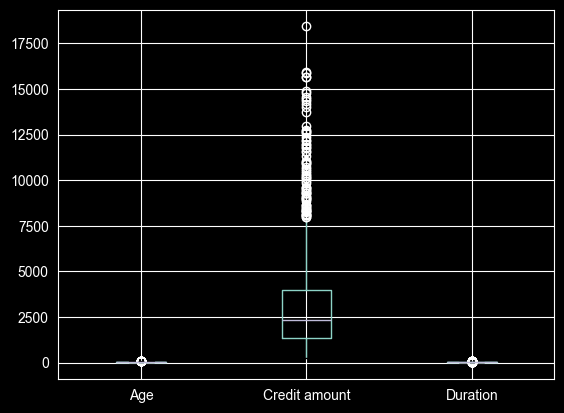

In [64]:
numeric_cols = ["Age", "Credit amount", "Duration"]
data_frame[numeric_cols].boxplot()
plt.show()

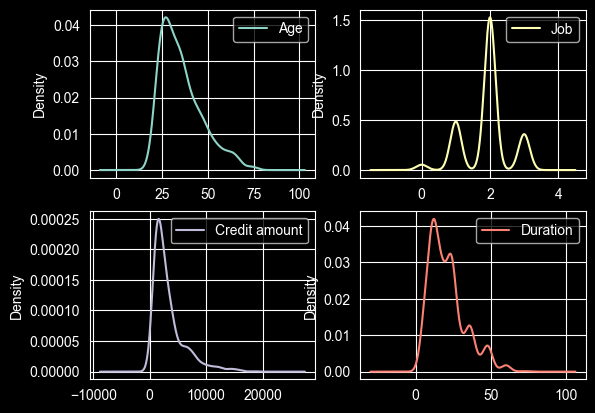

In [65]:
data_frame.plot(kind='density', subplots=True, layout=(2,2), sharex=False)
plt.show()

There is large difference in value for credit amount and others - for better results we should scale them.

In [66]:
data_frame_scaled = data_frame.select_dtypes(include=["int64"]).copy().drop("Job", axis=1)

scaler = StandardScaler()
data_frame_scaled[data_frame_scaled.columns] = scaler.fit_transform(data_frame_scaled)

data_frame_scaled.head()

,Age,Credit amount,Duration
0,2.766456,-0.745131,-1.236478
1,-1.191404,0.949817,2.248194
2,1.183312,-0.416562,-0.738668
3,0.831502,1.634247,1.750384
4,1.535122,0.566664,0.256953


### **VISUALIZATION**

<Axes: >

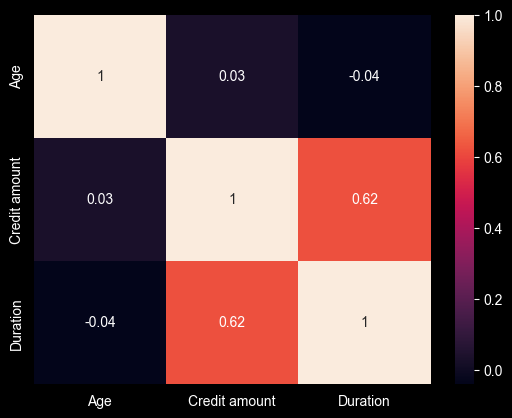

In [67]:
correlation_matrix = data_frame_scaled.corr(numeric_only=True).round(2)
sn.heatmap(data=correlation_matrix, annot=True)

## **MODEL**

### **FIRST MODEL** - DEFAULT PARAMS

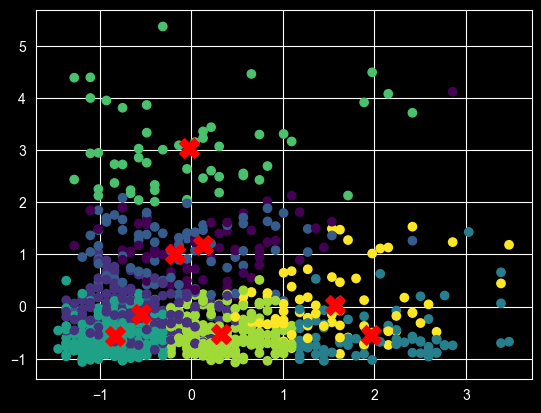

In [68]:
k_means_default = KMeans(n_init='auto', init='k-means++', max_iter=10000, random_state=21, algorithm="lloyd")

k_means_default_fitted = k_means_default.fit(data_frame_scaled)
k_means_default_fitted_labels = k_means_default_fitted.labels_
k_means_default_fitted_centers = k_means_default_fitted.cluster_centers_

plt.scatter(data_frame_scaled.iloc[:, 0], data_frame_scaled.iloc[:, 1], c = k_means_default_fitted_labels, cmap='viridis')
plt.scatter(k_means_default_fitted_centers[:, 0], k_means_default_fitted_centers[:, 1], s=200, c='red', marker='X')
plt.show()

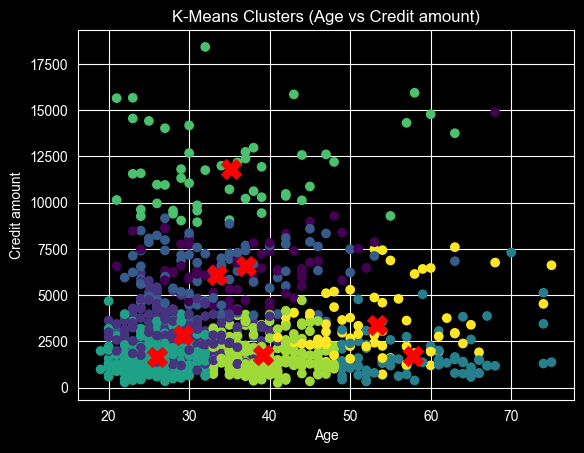

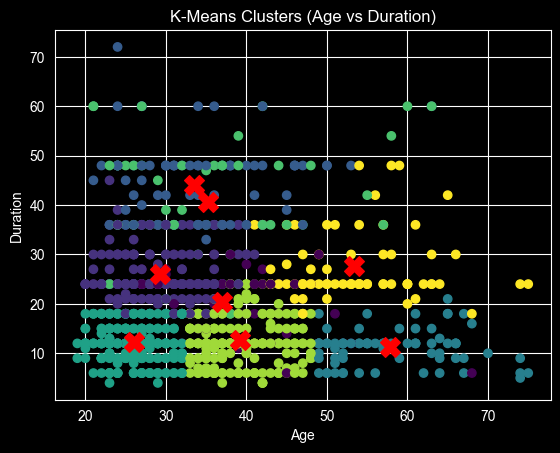

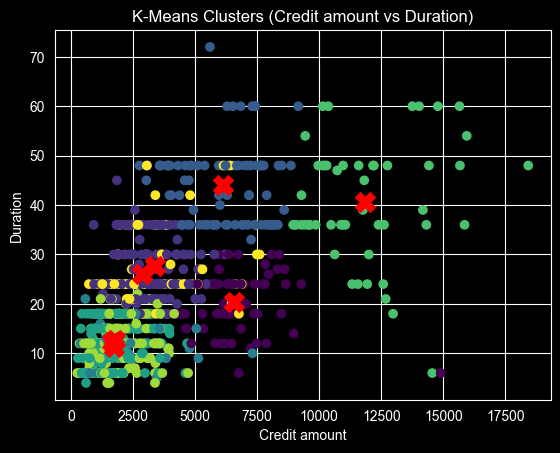

In [69]:
data_frame_for_kmeans = data_frame[["Age", "Credit amount", "Duration"]].copy()
k_means_default_fitted_centers_original = scaler.inverse_transform(k_means_default_fitted_centers)

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Credit amount"],
    c=k_means_default_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_default_fitted_centers_original[:, 0],
    k_means_default_fitted_centers_original[:, 1],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Age")
plt.ylabel("Credit amount")
plt.title("K-Means Clusters (Age vs Credit amount)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Duration"],
    c=k_means_default_fitted_labels,
    cmap='viridis'
)

plt.scatter(
    k_means_default_fitted_centers_original[:, 0],
    k_means_default_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)

plt.xlabel("Age")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Age vs Duration)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Credit amount"],
    data_frame_for_kmeans["Duration"],
    c=k_means_default_fitted_labels,
    cmap='viridis'
)

plt.scatter(
    k_means_default_fitted_centers_original[:, 1],
    k_means_default_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)

plt.xlabel("Credit amount")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Credit amount vs Duration)")
plt.show()

### **SECOND MODEL** - RANDOM PARAMS

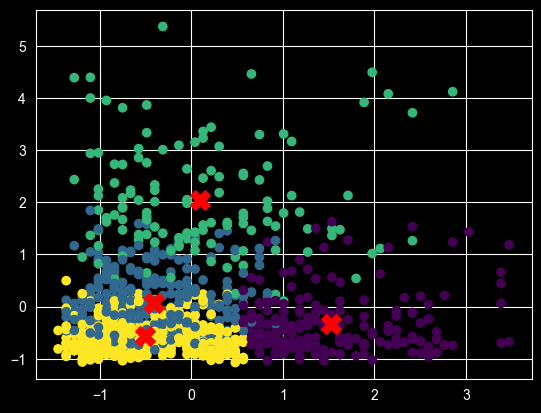

In [70]:
k_means_random = KMeans(n_clusters = 4, n_init='auto', init='k-means++', max_iter=10000, random_state=21, algorithm="lloyd")

k_means_random_fitted = k_means_random.fit(data_frame_scaled)
k_means_random_fitted_labels = k_means_random_fitted.labels_
k_means_random_fitted_centers = k_means_random_fitted.cluster_centers_

plt.scatter(data_frame_scaled.iloc[:, 0], data_frame_scaled.iloc[:, 1], c = k_means_random_fitted_labels, cmap='viridis')
plt.scatter(k_means_random_fitted_centers[:, 0], k_means_random_fitted_centers[:, 1], s=200, c='red', marker='X')
plt.show()

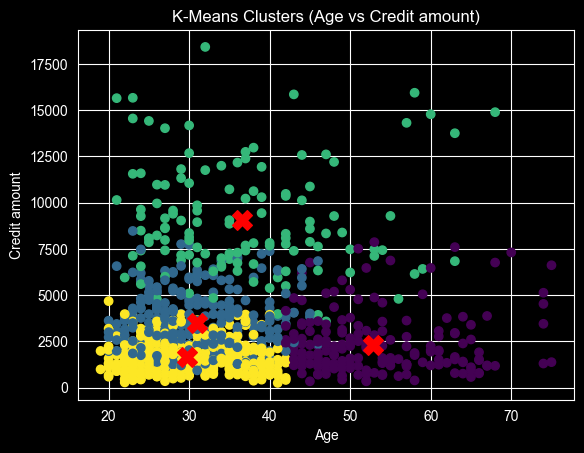

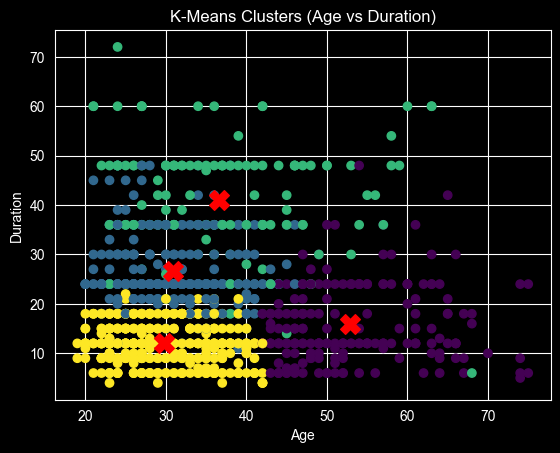

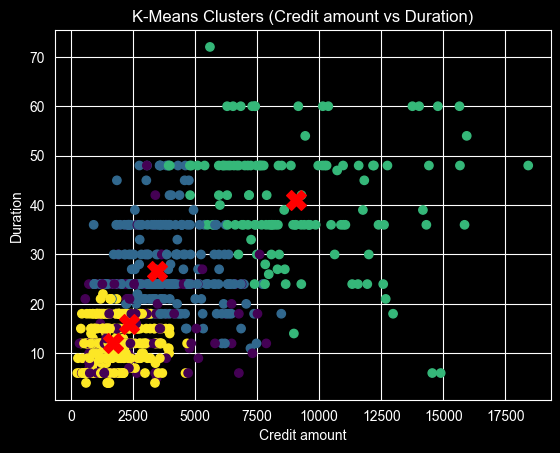

In [71]:
k_means_random_fitted_centers_original = scaler.inverse_transform(k_means_random_fitted_centers)

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Credit amount"],
    c=k_means_random_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_random_fitted_centers_original[:, 0],
    k_means_random_fitted_centers_original[:, 1],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Age")
plt.ylabel("Credit amount")
plt.title("K-Means Clusters (Age vs Credit amount)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Duration"],
    c=k_means_random_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_random_fitted_centers_original[:, 0],
    k_means_random_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Age")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Age vs Duration)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Credit amount"],
    data_frame_for_kmeans["Duration"],
    c=k_means_random_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_random_fitted_centers_original[:, 1],
    k_means_random_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Credit amount")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Credit amount vs Duration)")
plt.show()

### **THIRD MODEL** - IMPROVED PARAMS

Checking the quality of previous models based on Elbow and Silhouette method.

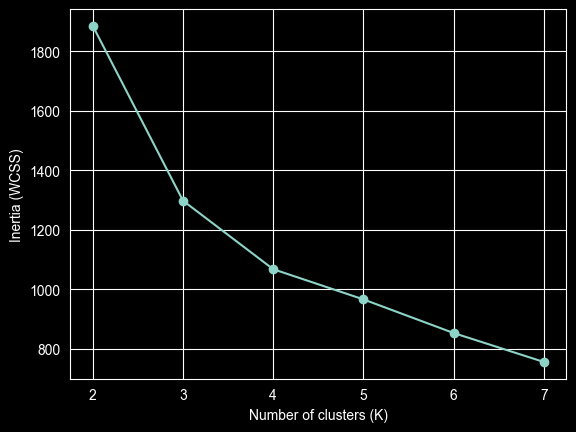

In [72]:
k_ranges = range(2, 8)

elbow_inertia = []

for k in k_ranges:
    k_means_elbow = KMeans(n_clusters = k, n_init='auto', init='k-means++', max_iter=10000, random_state=21, algorithm="lloyd")
    k_means_elbow.fit(data_frame_scaled)
    elbow_inertia.append(k_means_elbow.inertia_)


plt.plot(k_ranges, elbow_inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.show()

From the Elbow plot we can see possible candidates as 2, 3 or 4.

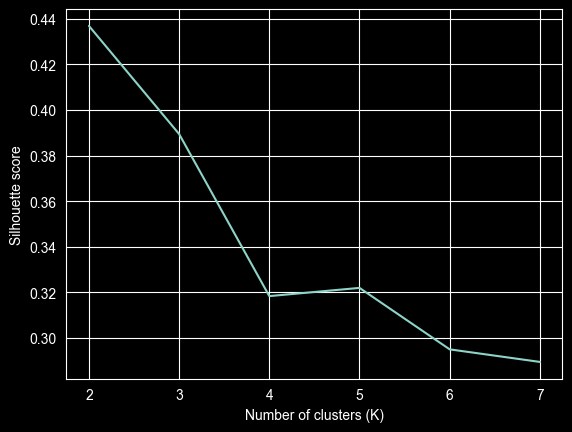

In [73]:
silhouette_scores = []

for k in k_ranges:
    k_means_silhouette = KMeans(n_clusters = k, n_init='auto', init='k-means++', max_iter=10000, random_state=21, algorithm="lloyd")
    k_means_silhouette_labels = k_means_silhouette.fit_predict(data_frame_scaled)
    k_means_silhouette_score = silhouette_score(data_frame_scaled, k_means_silhouette_labels)
    silhouette_scores.append(k_means_silhouette_score)

plt.plot(k_ranges, silhouette_scores)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.show()

We should pick K with the highest silhouette score, meaning **2**.

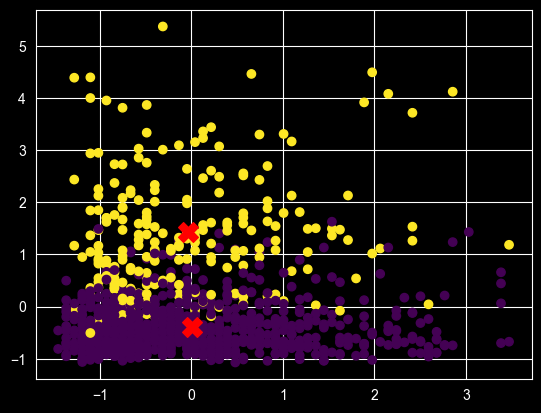

In [74]:
k_means_improved = KMeans(n_clusters = 2, n_init='auto', init='k-means++', max_iter=10000, random_state=21, algorithm="lloyd")

k_means_improved_fitted = k_means_improved.fit(data_frame_scaled)
k_means_improved_fitted_labels = k_means_improved_fitted.labels_
k_means_improved_fitted_centers = k_means_improved_fitted.cluster_centers_

plt.scatter(data_frame_scaled.iloc[:, 0], data_frame_scaled.iloc[:, 1], c = k_means_improved_fitted_labels, cmap='viridis')
plt.scatter(k_means_improved_fitted_centers[:, 0], k_means_improved_fitted_centers[:, 1], s=200, c='red', marker='X')
plt.show()

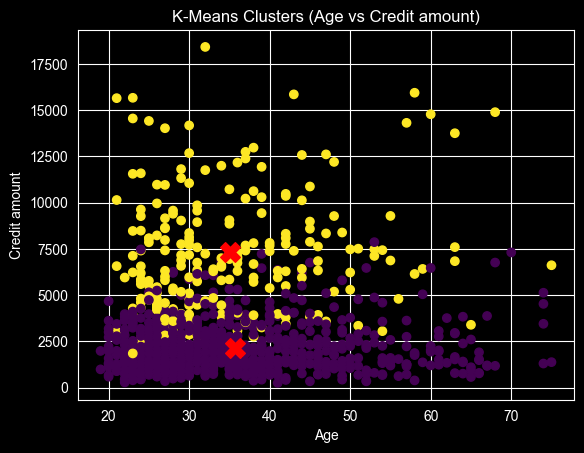

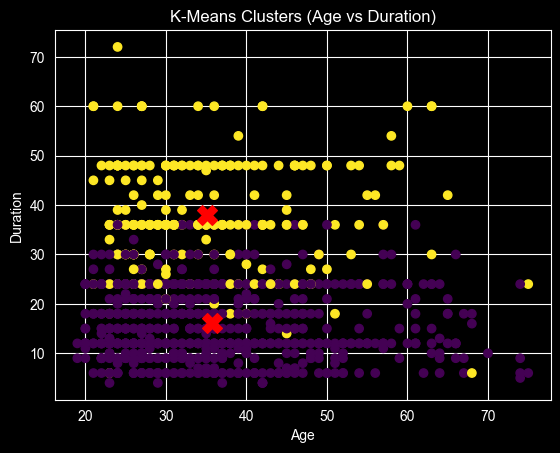

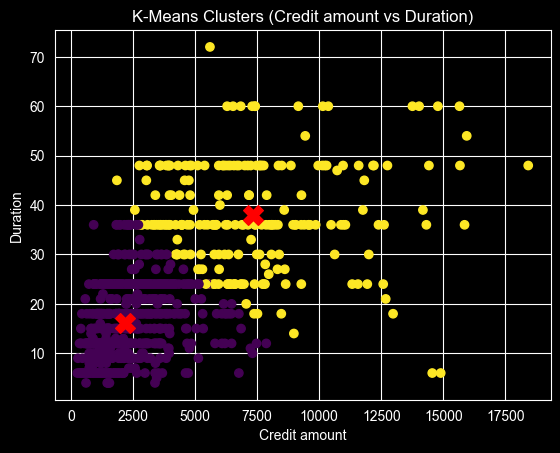

In [75]:
k_means_improved_fitted_centers_original = scaler.inverse_transform(k_means_improved_fitted_centers)

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Credit amount"],
    c=k_means_improved_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_improved_fitted_centers_original[:, 0],
    k_means_improved_fitted_centers_original[:, 1],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Age")
plt.ylabel("Credit amount")
plt.title("K-Means Clusters (Age vs Credit amount)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Age"],
    data_frame_for_kmeans["Duration"],
    c=k_means_improved_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_improved_fitted_centers_original[:, 0],
    k_means_improved_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Age")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Age vs Duration)")
plt.show()

plt.scatter(
    data_frame_for_kmeans["Credit amount"],
    data_frame_for_kmeans["Duration"],
    c=k_means_improved_fitted_labels,
    cmap='viridis'
)
plt.scatter(
    k_means_improved_fitted_centers_original[:, 1],
    k_means_improved_fitted_centers_original[:, 2],
    s=200,
    c="red",
    marker="X"
)
plt.xlabel("Credit amount")
plt.ylabel("Duration")
plt.title("K-Means Clusters (Credit amount vs Duration)")
plt.show()